**Cell 1: setup + exact solution**

device: cuda


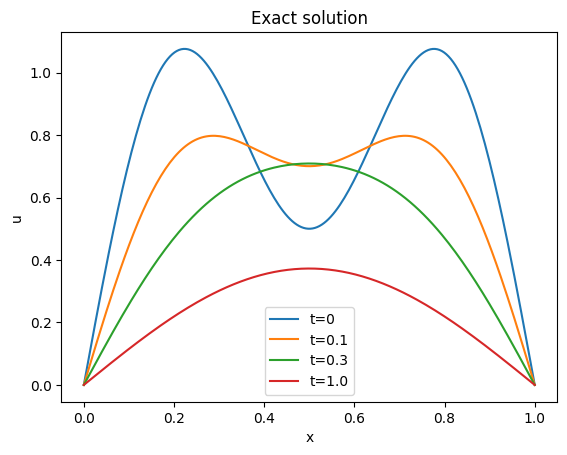

IC error: 0.0
BC values: 0.0 7.692846132661075e-17


In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

ALPHA = 0.1          # thermal diffusivity (nondimensional)
L, T = 1.0, 1.0      # rod length, final time

def u0(x):           # initial temperature profile (works for numpy or torch via the lambda below)
    return np.sin(np.pi*x) + 0.5*np.sin(3*np.pi*x)

def exact(x, t):     # Fourier-series solution: each mode decays as exp(-(n*pi)^2 * alpha * t)
    return (np.exp(-ALPHA*np.pi**2*t)*np.sin(np.pi*x)
            + 0.5*np.exp(-9*ALPHA*np.pi**2*t)*np.sin(3*np.pi*x))

# Sanity check: plot exact profile at a few times
x = np.linspace(0, L, 200)
for t in [0, 0.1, 0.3, 1.0]:
    plt.plot(x, exact(x, t), label=f"t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.title("Exact solution")
plt.show()

# Check that exact solution satisfies the IC and BC
print("IC error:", np.abs(exact(x, 0) - u0(x)).max())
print("BC values:", exact(0.0, 0.5), exact(L, 0.5))

**Cell 2: 2-input PINN + autograd derivatives**

In [2]:
def make_grid_pts(n):
    """n random points in [0,1]^2 as separate x, t columns (shape n x 1) that track gradients"""
    x = torch.rand(n, 1, device=device, requires_grad=True)
    t = torch.rand(n, 1, device=device, requires_grad=True)
    return x, t

class PINN(nn.Module):
    def __init__(self, hidden=32, layers=4):
        super().__init__()
        dims = [2] + [hidden]*layers + [1]          # 2 inputs (x,t) -> 1 output u
        mods = []
        for i in range(len(dims)-1):
            mods.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims)-2: mods.append(nn.Tanh())   # tanh: smooth 2nd derivatives
        self.net = nn.Sequential(*mods)
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))   # stack columns -> (N, 2)

def derivs(f, x, t):
    """Return u, u_t, u_xx for any function f(x,t). create_graph=True keeps the graph
    so we can differentiate again (and later backprop the loss through these)."""
    u   = f(x, t)
    ones = torch.ones_like(u)
    u_t  = torch.autograd.grad(u,   t, ones, create_graph=True)[0]
    u_x  = torch.autograd.grad(u,   x, ones, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u, u_t, u_xx

# --- Test 1: model builds, parameter count ---
model = PINN(hidden=32, layers=4).to(device)
print("params:", sum(p.numel() for p in model.parameters()))

# --- Test 2: autograd is correct if the EXACT solution gives ~zero PDE residual ---
def exact_torch(x, t):
    return (torch.exp(-ALPHA*np.pi**2*t)*torch.sin(np.pi*x)
            + 0.5*torch.exp(-9*ALPHA*np.pi**2*t)*torch.sin(3*np.pi*x))

x, t = make_grid_pts(1000)
_, u_t, u_xx = derivs(exact_torch, x, t)
print("max |residual| of exact solution:", (u_t - ALPHA*u_xx).abs().max().item())

# --- Test 3: untrained PINN runs through derivs, residual is large (expected) ---
_, u_t, u_xx = derivs(model, x, t)
print("untrained PINN residual (mean sq):", ((u_t - ALPHA*u_xx)**2).mean().item())

params: 3297
max |residual| of exact solution: 7.152557373046875e-07
untrained PINN residual (mean sq): 0.0021552725229412317


**Cell 3: sampling points + weighted loss**

In [3]:
# ---- fixed training points (drawn once; L-BFGS needs a fixed set) ----
N_PDE, N_IC, N_BC = 5000, 200, 200

x_pde, t_pde = make_grid_pts(N_PDE)                        # interior, need grads

x_ic = torch.rand(N_IC, 1, device=device)                  # t = 0 line
t_ic = torch.zeros_like(x_ic)
u_ic = torch.sin(np.pi*x_ic) + 0.5*torch.sin(3*np.pi*x_ic) # target u0(x)

t_bc = torch.rand(N_BC, 1, device=device)                  # walls x = 0 and x = 1
x_bc0 = torch.zeros_like(t_bc)
x_bc1 = torch.ones_like(t_bc)

W_PDE, W_IC, W_BC = 1.0, 1.0, 1.0

def losses(model):
    # PDE residual, normalized by alpha (same trick as dividing by k in Project 1)
    _, u_t, u_xx = derivs(model, x_pde, t_pde)
    l_pde = ((u_t/ALPHA - u_xx)**2).mean()
    # Initial condition
    l_ic = ((model(x_ic, t_ic) - u_ic)**2).mean()
    # Boundary conditions (u = 0 at both walls)
    l_bc = (model(x_bc0, t_bc)**2).mean() + (model(x_bc1, t_bc)**2).mean()
    total = W_PDE*l_pde + W_IC*l_ic + W_BC*l_bc
    return total, l_pde, l_ic, l_bc

# ---- test: one evaluation + one backward pass ----
model = PINN(32, 4).to(device)
total, a, b, c = losses(model)
total.backward()
print(f"total {total.item():.4e} | pde {a.item():.4e} | ic {b.item():.4e} | bc {c.item():.4e}")
print("grad norm:", sum(p.grad.norm()**2 for p in model.parameters()).sqrt().item())

total 6.5624e-01 | pde 1.6992e-01 | ic 2.6875e-01 | bc 2.1757e-01
grad norm: 5.8190813064575195


**Cell 4: training (Adam → L-BFGS, both logged)**

In [4]:
import time
torch.manual_seed(0)
model = PINN(32, 4).to(device)
hist = {"adam": [], "lbfgs": []}       # each entry: (total, pde, ic, bc)

# ---- Stage 1: Adam ----
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)
t0 = time.time()
for it in range(10000):
    opt.zero_grad()
    total, a, b, c = losses(model)
    total.backward()
    opt.step(); sched.step()
    hist["adam"].append([v.item() for v in (total, a, b, c)])
    if it % 1000 == 0:
        print(f"adam {it:5d} | total {total.item():.3e} | pde {a.item():.2e} | ic {b.item():.2e} | bc {c.item():.2e}")
print(f"Adam done in {time.time()-t0:.0f}s")

# ---- Stage 2: L-BFGS (closure re-evaluates loss + grads; we log each call) ----
lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, history_size=50,
                          line_search_fn="strong_wolfe",
                          tolerance_grad=1e-12, tolerance_change=1e-14)
def closure():
    lbfgs.zero_grad()
    total, a, b, c = losses(model)
    total.backward()
    hist["lbfgs"].append([v.item() for v in (total, a, b, c)])
    return total
lbfgs.step(closure)
print("L-BFGS evals:", len(hist["lbfgs"]), "| final total:", f"{hist['lbfgs'][-1][0]:.3e}")

# ---- quick accuracy check on a grid ----
xg, tg = np.meshgrid(np.linspace(0,1,101), np.linspace(0,1,101))
xt = torch.tensor(xg.reshape(-1,1), dtype=torch.float32, device=device)
tt = torch.tensor(tg.reshape(-1,1), dtype=torch.float32, device=device)
with torch.no_grad():
    up = model(xt, tt).cpu().numpy().reshape(xg.shape)
print("max abs error:", np.abs(up - exact(xg, tg)).max())

adam     0 | total 1.230e+00 | pde 2.15e-01 | ic 9.60e-01 | bc 5.46e-02
adam  1000 | total 9.932e-02 | pde 7.46e-04 | ic 8.10e-02 | bc 1.76e-02
adam  2000 | total 9.700e-02 | pde 7.48e-04 | ic 8.15e-02 | bc 1.48e-02
adam  3000 | total 9.417e-02 | pde 8.98e-04 | ic 8.00e-02 | bc 1.32e-02
adam  4000 | total 8.882e-02 | pde 1.48e-03 | ic 7.61e-02 | bc 1.12e-02
adam  5000 | total 8.158e-02 | pde 2.04e-03 | ic 7.02e-02 | bc 9.29e-03
adam  6000 | total 7.258e-02 | pde 1.82e-03 | ic 6.32e-02 | bc 7.58e-03
adam  7000 | total 6.584e-02 | pde 2.41e-03 | ic 5.70e-02 | bc 6.42e-03
adam  8000 | total 5.913e-02 | pde 2.81e-03 | ic 5.08e-02 | bc 5.55e-03
adam  9000 | total 5.156e-02 | pde 3.36e-03 | ic 4.34e-02 | bc 4.76e-03
Adam done in 101s
L-BFGS evals: 525 | final total: 6.305e-04
max abs error: 0.01672661304473877


**Cell 4b: weight experiment**

In [5]:
import copy
model_base = copy.deepcopy(model)   # baseline (weights 1,1,1), error 1.67e-2

def max_err(m):
    with torch.no_grad():
        return np.abs(m(xt, tt).cpu().numpy().reshape(xg.shape) - exact(xg, tg)).max()

def train(w_pde, w_ic, w_bc, adam_steps=10000):
    global W_PDE, W_IC, W_BC
    W_PDE, W_IC, W_BC = w_pde, w_ic, w_bc
    torch.manual_seed(0)
    m = PINN(32, 4).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)
    for it in range(adam_steps):
        opt.zero_grad(); total, a, b, c = losses(m); total.backward()
        opt.step(); sched.step()
    print(f"  after Adam:  ic {b.item():.2e} pde {a.item():.2e} | err {max_err(m):.2e}")
    lb = torch.optim.LBFGS(m.parameters(), max_iter=500, history_size=50,
                           line_search_fn="strong_wolfe", tolerance_grad=1e-12, tolerance_change=1e-14)
    def cl():
        lb.zero_grad(); total, *_ = losses(m); total.backward(); return total
    lb.step(cl)
    print(f"  after LBFGS: err {max_err(m):.2e}")
    return m

print("weights (1, 20, 20):")
model_w = train(1.0, 20.0, 20.0)

weights (1, 20, 20):
  after Adam:  ic 1.71e-06 pde 7.11e-04 | err 2.79e-03
  after LBFGS: err 2.75e-03


**Cell 5: validation against exact + finite differences**

PINN vs exact : max 2.75e-03 | rel L2 1.27e-03
FD   vs exact : max 7.01e-05 | rel L2 4.91e-05
PINN vs FD    : max 2.75e-03


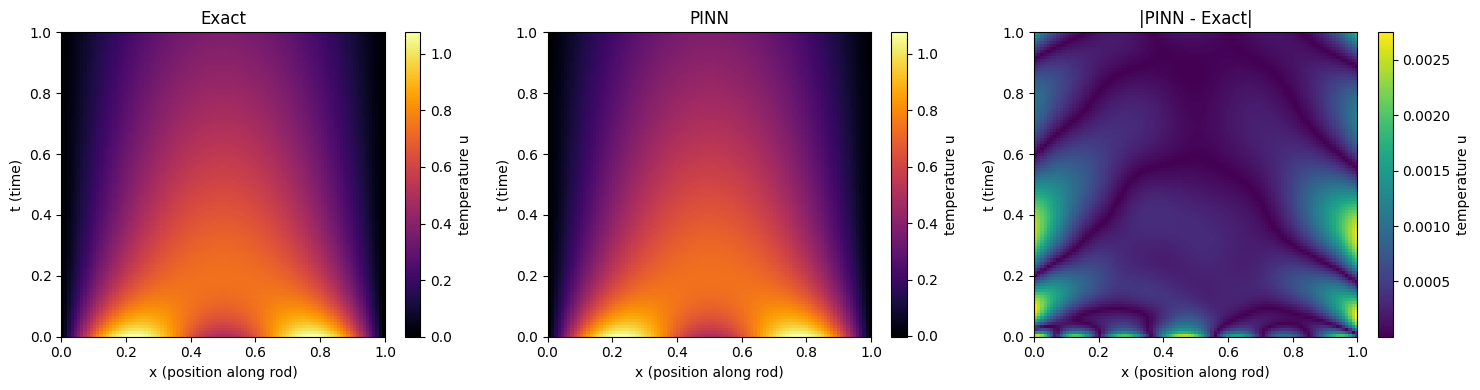

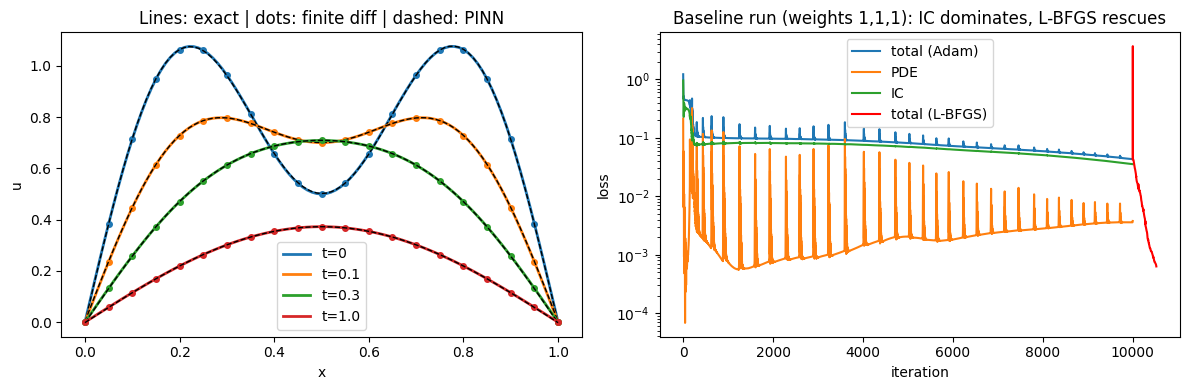

In [6]:
import os
os.makedirs("figures", exist_ok=True)

# ---- Finite-difference reference (explicit FTCS), saved on the same 101x101 grid ----
nx, dx = 101, 0.01
dt = 2.5e-4                      # r = ALPHA*dt/dx^2 = 0.25 (stable)
r = ALPHA*dt/dx**2
xs = np.linspace(0, 1, nx)
U = np.sin(np.pi*xs) + 0.5*np.sin(3*np.pi*xs)
U[0] = U[-1] = 0
fd = [U.copy()]                  # fd[k] = profile at t = k*0.01
for k in range(100):             # 100 saves x 40 steps x dt = t up to 1.0
    for _ in range(40):
        U[1:-1] += r*(U[2:] - 2*U[1:-1] + U[:-2])
    fd.append(U.copy())
fd = np.array(fd)                # shape (101 time, 101 x) -> same layout as xg, tg

# ---- PINN prediction with the weighted model ----
with torch.no_grad():
    up = model_w(xt, tt).cpu().numpy().reshape(xg.shape)
ue = exact(xg, tg)

print(f"PINN vs exact : max {np.abs(up-ue).max():.2e} | rel L2 {np.linalg.norm(up-ue)/np.linalg.norm(ue):.2e}")
print(f"FD   vs exact : max {np.abs(fd-ue).max():.2e} | rel L2 {np.linalg.norm(fd-ue)/np.linalg.norm(ue):.2e}")
print(f"PINN vs FD    : max {np.abs(up-fd).max():.2e}")

# ---- Figure 1: heatmaps ----
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a_, Z, ttl in zip(ax, [ue, up, np.abs(up-ue)], ["Exact", "PINN", "|PINN - Exact|"]):
    im = a_.imshow(Z, origin="lower", extent=[0,1,0,1], aspect="auto",
                   cmap="inferno" if "|" not in ttl else "viridis")
    a_.set_title(ttl); a_.set_xlabel("x (position along rod)"); a_.set_ylabel("t (time)")
    plt.colorbar(im, ax=a_, label="temperature u")
plt.tight_layout(); plt.savefig("figures/heatmaps.png", dpi=150); plt.show()

# ---- Figure 2: profiles (exact line, FD dots, PINN dashed) + baseline loss curves ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for tv, c in zip([0, 0.1, 0.3, 1.0], ["C0","C1","C2","C3"]):
    k = int(round(tv*100))
    ax[0].plot(xs, ue[k], c, lw=2, label=f"t={tv}")
    ax[0].plot(xs[::5], fd[k][::5], c+"o", ms=4)
    ax[0].plot(xs, up[k], "k--", lw=1)
ax[0].set_title("Lines: exact | dots: finite diff | dashed: PINN")
ax[0].set_xlabel("x"); ax[0].set_ylabel("u"); ax[0].legend()

ha, hl = np.array(hist["adam"]), np.array(hist["lbfgs"])
n = len(ha)
ax[1].semilogy(range(n), ha[:,0], label="total (Adam)")
ax[1].semilogy(range(n), ha[:,1], label="PDE"); ax[1].semilogy(range(n), ha[:,2], label="IC")
ax[1].semilogy(range(n, n+len(hl)), hl[:,0], "r", label="total (L-BFGS)")
ax[1].set_title("Baseline run (weights 1,1,1): IC dominates, L-BFGS rescues")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("loss"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/profiles_loss.png", dpi=150); plt.show()

**Cell 6: animation**

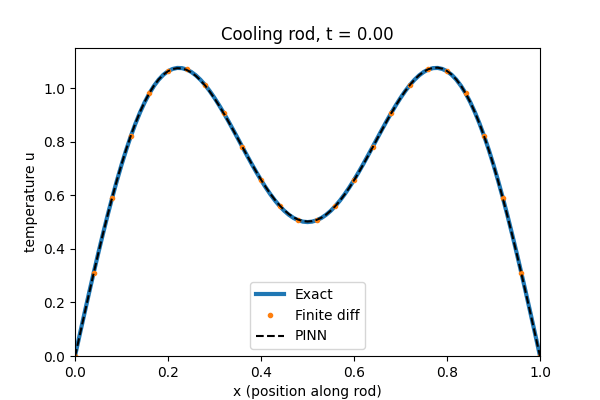

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, 1); ax.set_ylim(0, 1.15)
ax.set_xlabel("x (position along rod)"); ax.set_ylabel("temperature u")
l_ex, = ax.plot([], [], "C0", lw=3, label="Exact")
l_fd, = ax.plot([], [], "C1o", ms=3, label="Finite diff")
l_pn, = ax.plot([], [], "k--", lw=1.5, label="PINN")
ax.legend(loc="lower center")

def update(k):                       # k = time index, t = k*0.01
    l_ex.set_data(xs, ue[k])
    l_fd.set_data(xs[::4], fd[k][::4])
    l_pn.set_data(xs, up[k])
    ax.set_title(f"Cooling rod, t = {k*0.01:.2f}")
    return l_ex, l_fd, l_pn

anim = FuncAnimation(fig, update, frames=range(0, 101, 2))
anim.save("figures/heat.gif", writer=PillowWriter(fps=15), dpi=100)
plt.close(fig)
Image("figures/heat.gif")